# Entrega 3 
### Problema de abandono en banco - Kaggle 
#### Equipo: Enrique De Martini, Esteban Cardoso, Lucas Barrios  

In [1]:
# 00. IMPORTAR LIBRERIAS GENERALES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', '{:.2f}'.format)
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/estebancardoso96/grupo_3/main/train.csv"

df = pd.read_csv(url)

# Creo una copia del dataframe original por si luego quiero utilizar alguna variable sin modificaciones 
copia_cruda_df = df.copy()

### 1) - Análisis Exploratrio (EDA)

In [3]:
# 02. REALIZAR UNA INSPECCION INICIAL DEL DATASET TRAIN.CSV ---

print("AUDITORIA DE VARIABLES")

print(f"\nDimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas\n")

audit = pd.DataFrame({
    'dtype':          df.dtypes,
    'nulos':          df.isnull().sum(),
    'pct_nulos':      (df.isnull().sum() / len(df) * 100).round(2),
    'valores_únicos': df.nunique(),
    'ejemplo':        df.sample(1).iloc[0], # Genera muestra aleatoria y extrae primera fila
    })
audit

AUDITORIA DE VARIABLES

Dimensiones del dataset: 15000 filas × 14 columnas



,dtype,nulos,pct_nulos,valores_únicos,ejemplo
id,int64,0,0.00,15000,5650
CustomerId,float64,0,0.00,6309,15640258.00
Surname,object,0,0.00,763,Genovese
CreditScore,float64,0,0.00,378,645.00
Geography,object,0,0.00,3,Spain
Gender,object,0,0.00,2,Female
Age,float64,0,0.00,55,38.00
Tenure,float64,0,0.00,11,6.00
Balance,float64,0,0.00,3328,0.00
NumOfProducts,float64,0,0.00,4,2.00


In [4]:
# 03. VERIFICAR PARA VARIABLES NUMERICAS SI TIENEN REGISTROS CON PARTE DECIMAL

col_a_verificar = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember', 
    'Exited'
]

col_sin_decimales = []
col_con_decimales = []

for col in col_a_verificar:
  # Calcular el resto de la división entera entre uno
  registros_con_decimales = (df[col] % 1 !=0).sum()

  if registros_con_decimales == 0:
    col_sin_decimales.append(col)
  else:
    col_con_decimales.append(col)

print("Columnnas numéricas SIN registros con decimales:")
display(col_sin_decimales)

print("\nColumnas numéricas CON registros con decimales:")
display(col_con_decimales)

Columnnas numéricas SIN registros con decimales:


['CreditScore',
 'Age',
 'Tenure',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'Exited']


Columnas numéricas CON registros con decimales:


['Balance']

In [5]:
# 04. ELIMINAR COLUMNAS QUE NO SE USARAN EN EL MODELO

col_eliminar =[
    'id',
    'CustomerId',
    'Surname'
]

df_depurado = df.drop(columns=col_eliminar)

In [6]:
df_depurado.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,658.13,37.74,5.00,42929.93,1.59,0.78,0.49,118535.94,0.20
std,73.26,8.18,2.81,59820.61,0.53,0.41,0.50,159223.34,0.40
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,600.00,32.00,3.00,0.00,1.00,1.00,0.00,82696.84,0.00
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,122964.18,0.00
75%,709.00,42.00,7.00,109733.20,2.00,1.00,1.00,156039.30,0.00
max,850.00,72.00,10.00,206329.65,4.00,1.00,1.00,18789543.34,1.00


In [7]:
# 05. COMPLETAR POR GRUPOS LISTA DE VARIABLES A USAR EN EL MODELO
# Antes realizo el log de 'EstimatedSalary' para que tenga una distribución más normal y no sesgada a la derecha
df_depurado['ln_EstimatedSalary'] = np.log1p(df_depurado['EstimatedSalary'])
df_depurado = df_depurado.drop(columns=['EstimatedSalary'])


num_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'ln_EstimatedSalary'
]

cat_features = [
    'Geography',
    'Gender'

]

bin_features = [
    'HasCrCard',
    'IsActiveMember'
]

target = 'Exited'

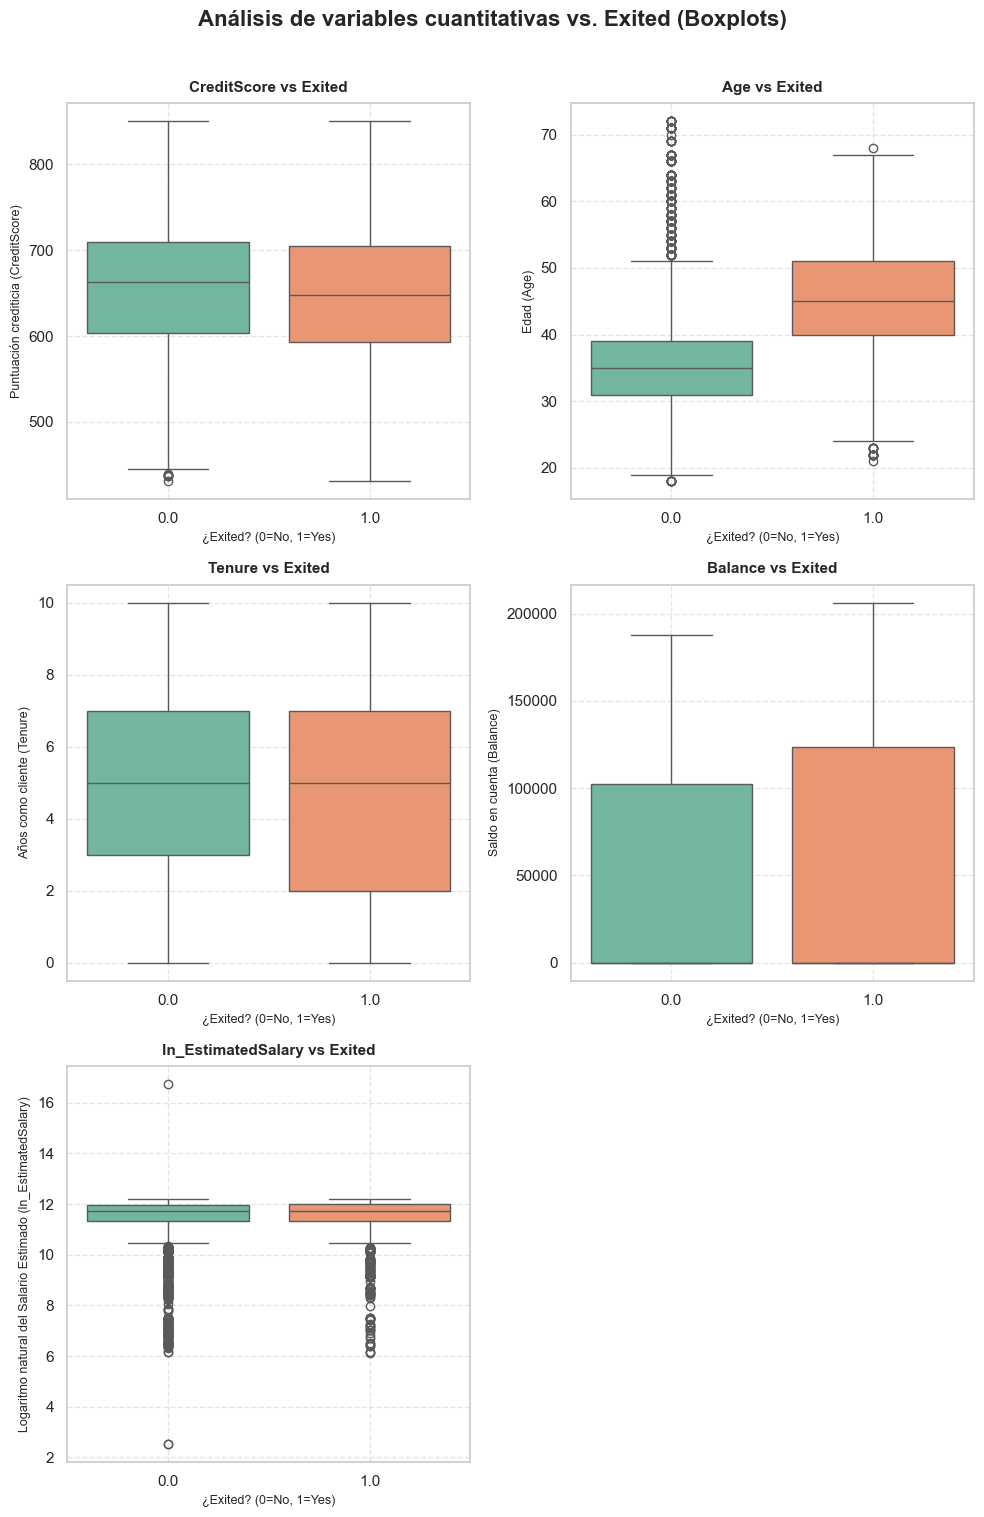

In [8]:
# 06. REALIZAR ANALISIS DE VARIABLES NUMERICAS VERSUS EXITED (BOXPLOTS)

# Definir las variables numéricas a analizar
variables_boxplot = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'ln_EstimatedSalary'
]

# Configurar el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Ajustar a una grilla de 3 filas y 2 columnas (6 cuadrantes en total)
# Redefinir el tamaño de la figura a un formato ideal (10 de base x 15 de alto)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))

# Aplanar la matriz de 4x4 para iterar linealmente del 0 al 15
axes_flat = axes.flat

# Mapear títulos amigables en español
titulos = {
    'CreditScore': 'Puntuación crediticia (CreditScore)',
    'Age': 'Edad (Age)',
    'Tenure': 'Años como cliente (Tenure)',
    'Balance': 'Saldo en cuenta (Balance)',
    'ln_EstimatedSalary': 'Logaritmo natural del Salario Estimado (ln_EstimatedSalary)'
}

# Iterar para construir cada Boxplot
for i, var in enumerate(variables_boxplot):
    ax = axes_flat[i]

    sns.boxplot(
        x=target,
        y=var,
        data=df_depurado,
        ax=ax,
        palette="Set2",
        hue=target,
        legend=False
    )

    # Adaptar títulos y etiquetas al ancho de las 2 columnas
    ax.set_title(f"{var} vs Exited", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel("¿Exited? (0=No, 1=Yes)", fontsize=9)
    ax.set_ylabel(titulos.get(var, var), fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Apagar cuadrantes vacíos
for j in range(len(variables_boxplot), len(axes_flat)):
    axes_flat[j].axis('off')

# Generar título general, ajustar layout y mostrar
plt.suptitle("Análisis de variables cuantitativas vs. Exited (Boxplots)", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

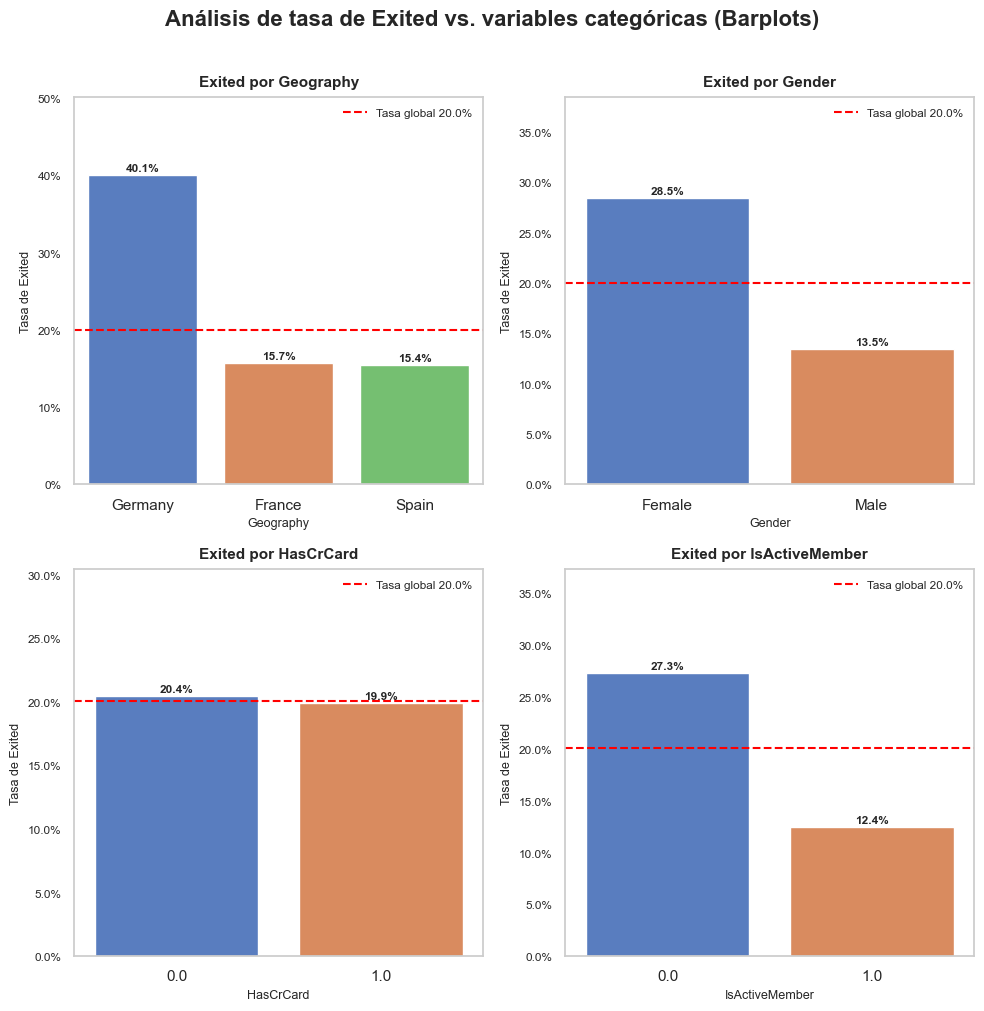

In [9]:
# 07. REALIZAR ANALISIS DE TASA DE ABANDONO VS VARIABLES CATEGORICAS / BINARIAS (BARPLOTS)

import matplotlib.ticker as mtick

# Definir las variables categóricas o binarias a analizar
variables_a_graficar = [
    'Geography',
    'Gender',
    'HasCrCard',
    'IsActiveMember'
]

# Calcular la tasa base real del dataset
tasa_base = df_depurado[target].mean()

# Configurar el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Crear una grilla de 2 filas y 2 columnas (4 cuadrantes)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
axes_flat = axes.flat

for i, var in enumerate(variables_a_graficar):
    ax = axes_flat[i]

    # Quitar las líneas de la grilla de fondo
    ax.grid(False)

    # Agrupar por la variable y calcular el promedio de Exited
    data_grafico = df_depurado.groupby(var)[target].mean().reset_index().sort_values(by=target, ascending=False)

    # Crear el gráfico de barras
    sns.barplot(
        x=var,
        y=target,
        data=data_grafico,
        palette="muted",
        hue=var,
        legend=False,
        ax=ax
    )

    # Dibujar la línea horizontal de la tasa base
    linea_base = ax.axhline(
        y=tasa_base,
        color='red',
        linestyle='--',
        linewidth=1.5
    )

    # Agregar leyenda en el borde superior derecho del gráfico
    ax.legend(
        [linea_base],
        [f'Tasa global {tasa_base*100:.1f}%'],
        loc='upper right',
        fontsize=8.5,
        frameon=True,
        facecolor='white',
        edgecolor='none'
    )

    # Configurar títulos y etiquetas específicos del cuadrante
    ax.set_title(f"Exited por {var}", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel("Tasa de Exited", fontsize=9)

    # Ajustar límite del eje Y dinámicamente dando un margen extra para la leyenda
    max_val = data_grafico[target].max()
    ax.set_ylim(0, max_val + 0.10 if max_val > 0 else 0.3)

    # Formatear el eje Y como porcentaje
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='y', labelsize=8.5)

    # Agregar las etiquetas de porcentaje sobre cada barra
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height*100:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=8.5, fontweight='bold')

# Ajustar el título general de la figura completa
plt.suptitle("Análisis de tasa de Exited vs. variables categóricas (Barplots)", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# 08. DIVISION DEL DATASET TRAIN EN CONJUNTO DE ENTRENAMIENTO Y PRUEBA

from sklearn.model_selection import train_test_split

X = df_depurado.drop(columns=[target])
y = df_depurado[target]

# Obtener dataset de entrenamiento y testeo con dataset desbalanceado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # stratify=y porque dataset desbalanceado

# Mostrar dataset completo sin variable respuesta
display(X)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,ln_EstimatedSalary
0,636.00,France,Male,36.00,9.00,0.00,1.00,1.00,1.00,10.89
1,742.00,France,Male,35.00,1.00,0.00,2.00,1.00,1.00,10.95
2,704.00,France,Female,38.00,5.00,161889.79,1.00,1.00,0.00,11.29
3,685.00,France,Female,38.00,0.00,0.00,2.00,1.00,0.00,11.38
4,708.00,France,Male,34.00,10.00,0.00,2.00,0.00,0.00,11.07
...,...,...,...,...,...,...,...,...,...,...
14995,580.00,Germany,Female,37.00,3.00,141806.00,2.00,1.00,0.00,11.93
14996,516.00,Spain,Female,38.00,4.00,0.00,2.00,1.00,0.00,12.05
14997,538.00,Germany,Female,43.00,7.00,129745.10,1.00,1.00,0.00,7.25
14998,616.00,France,Female,27.00,7.00,0.00,2.00,0.00,1.00,11.50


In [11]:
# 09. CONSTRUIR COLUMN TRANSFORMER

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocesador = ColumnTransformer(
    transformers=[
        ('escalar_num', StandardScaler(), num_features),
        ('codificar_cat', OneHotEncoder(drop='first', sparse_output=False), cat_features),
        ('codificar_bin', OneHotEncoder(drop='first', sparse_output=False), bin_features),
    ],
    remainder='drop'
)

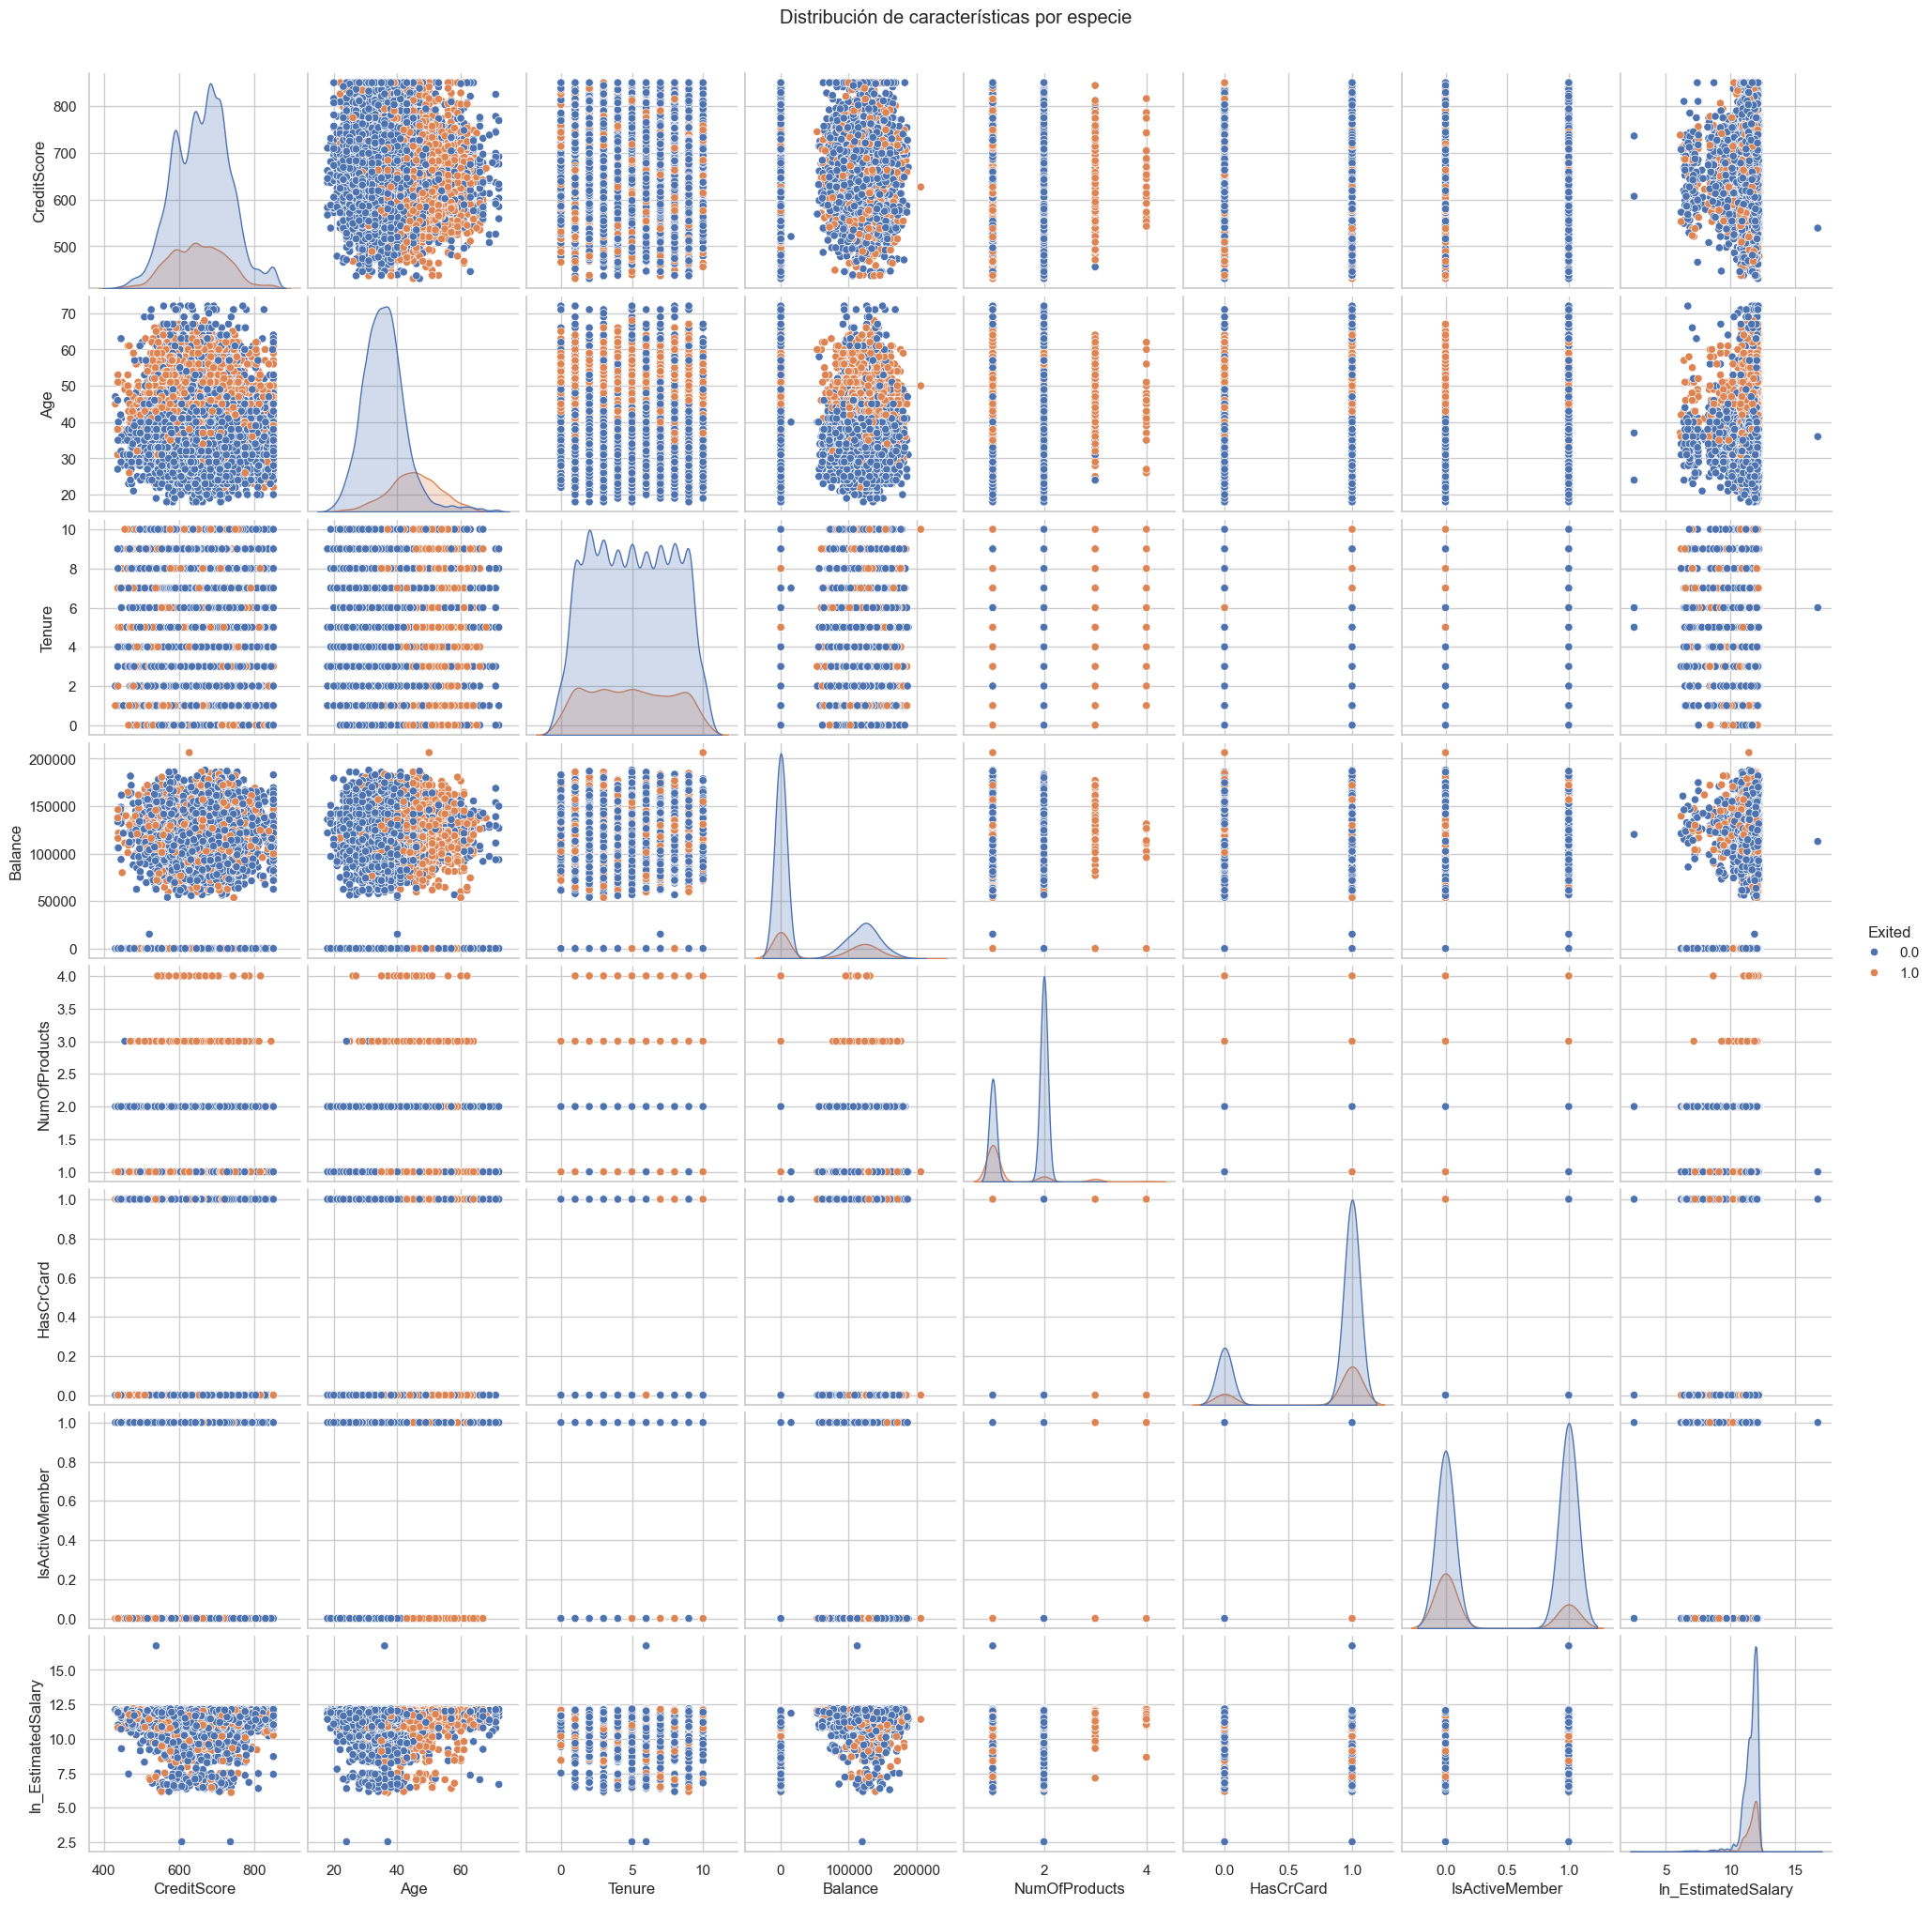

In [12]:
sns.pairplot(df_depurado, hue='Exited')
plt.suptitle("Distribución de características por especie", y=1.02)
plt.show()

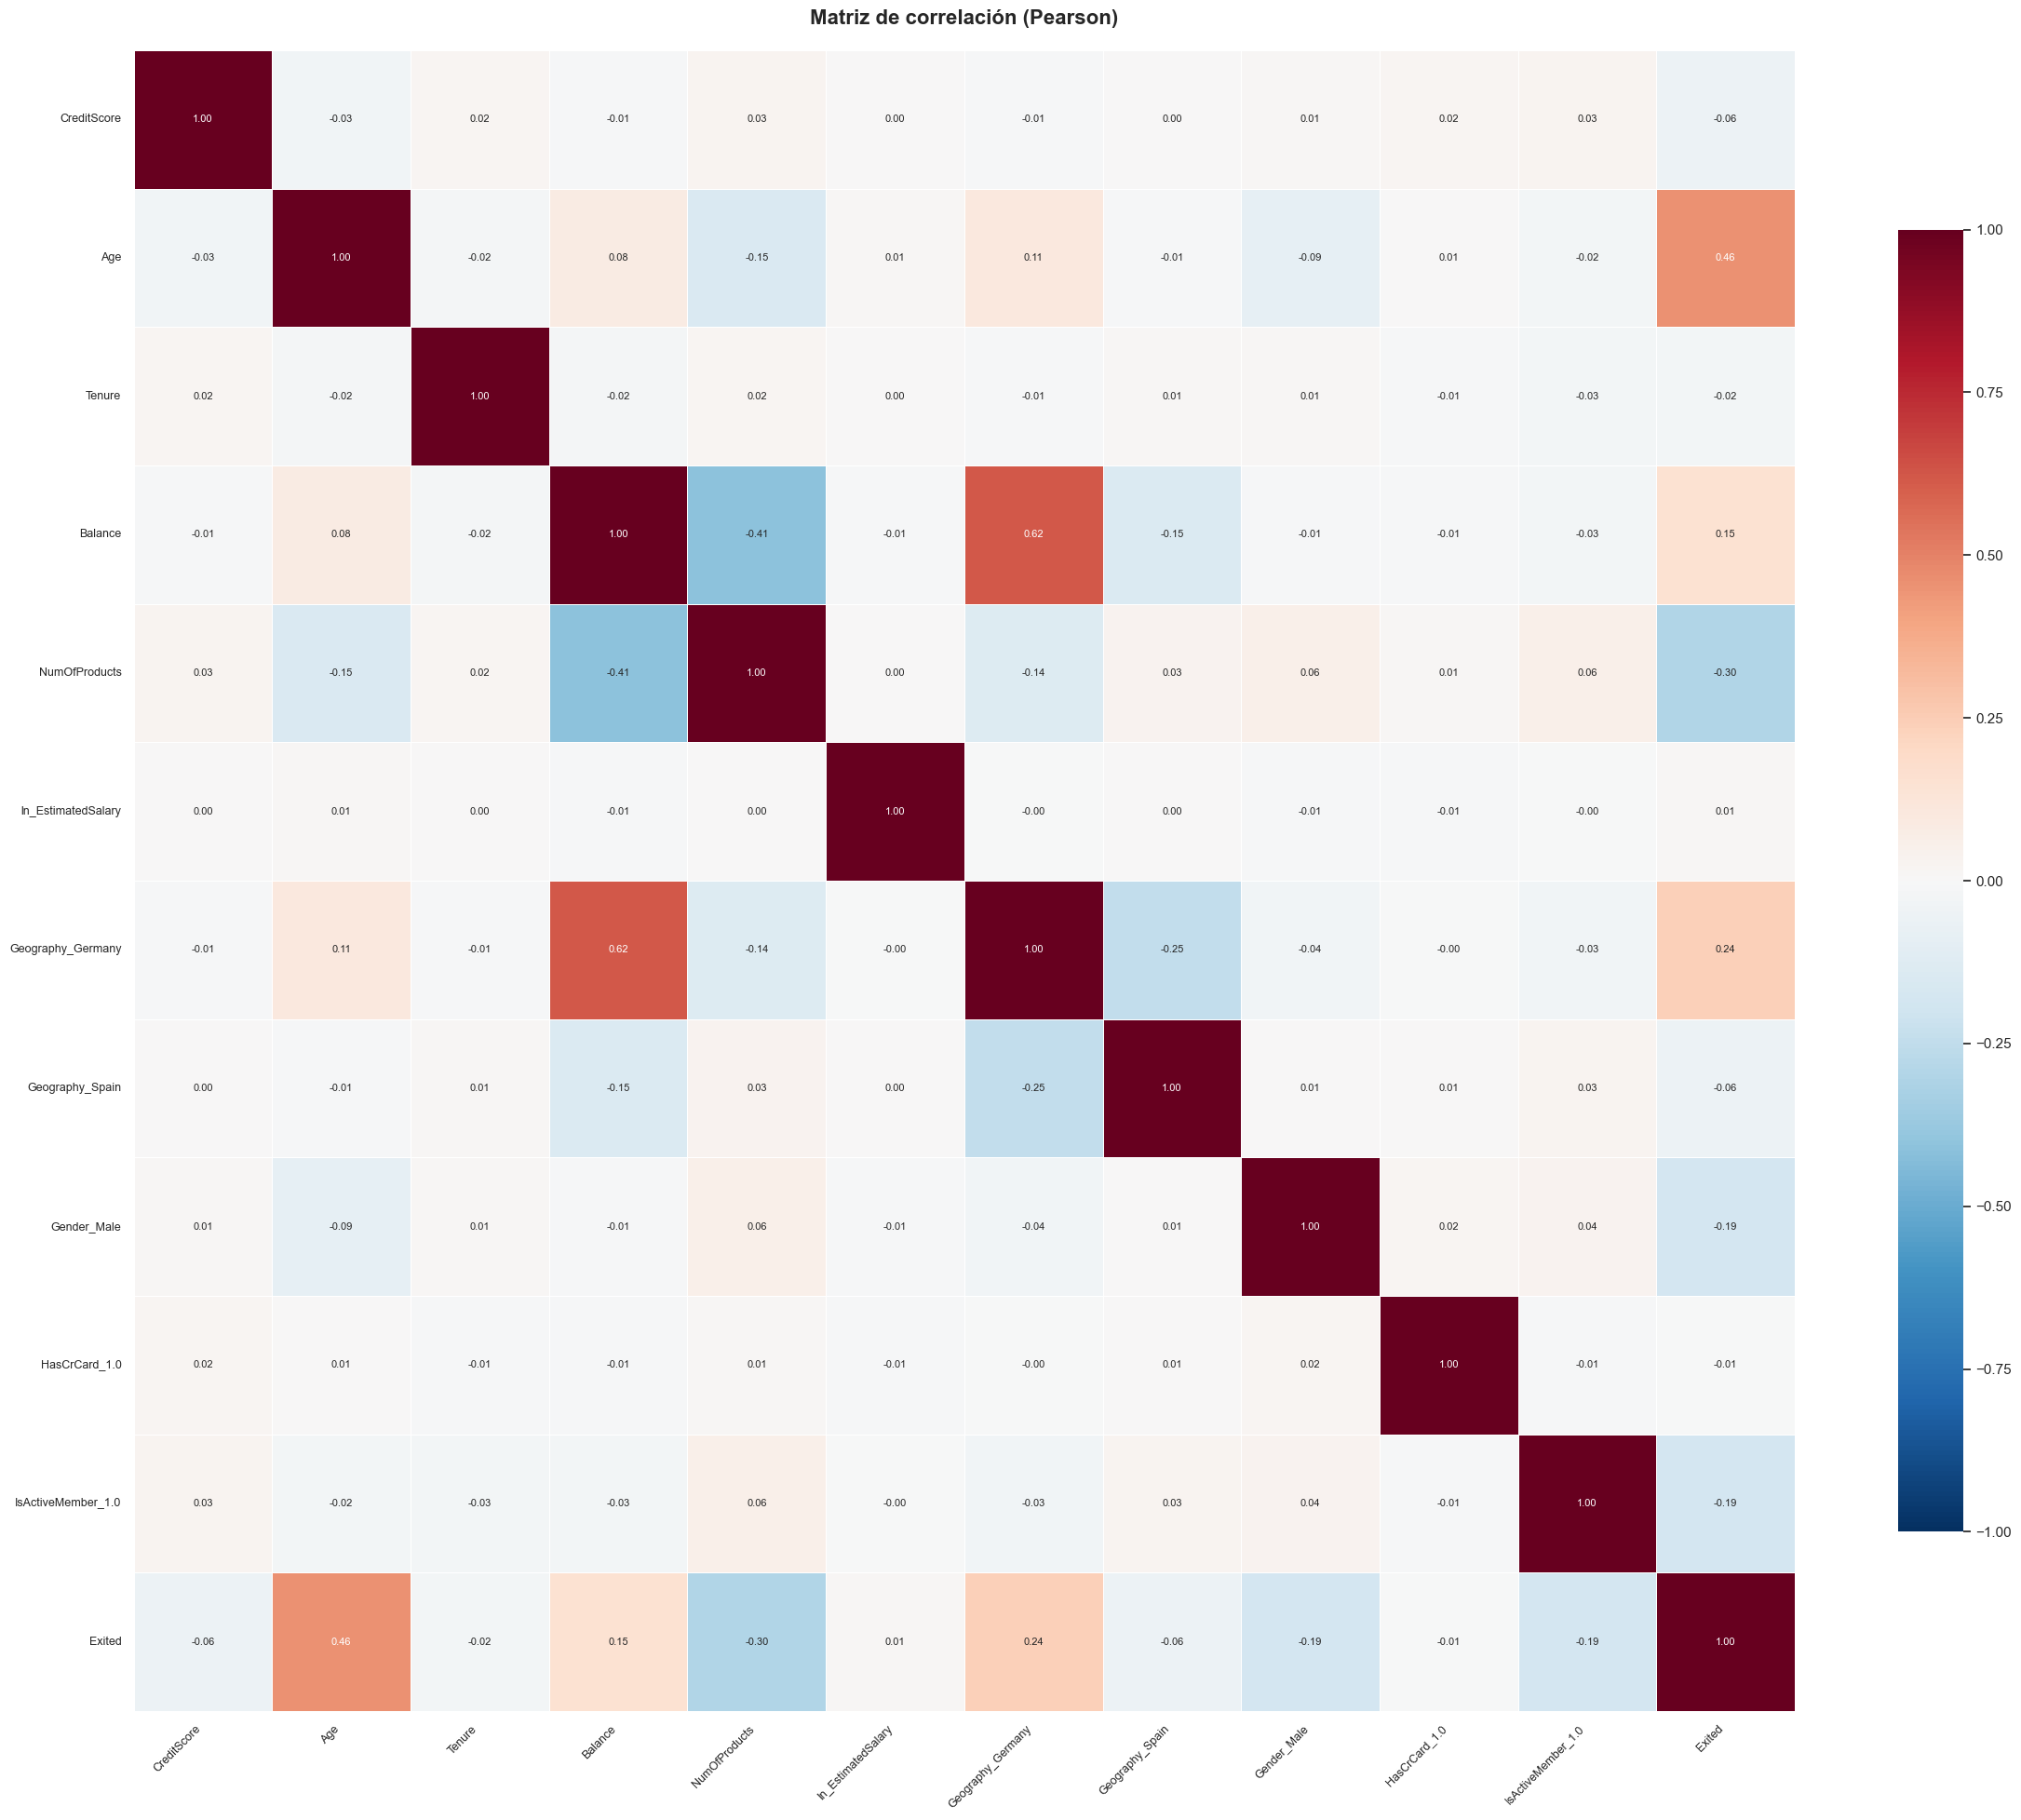

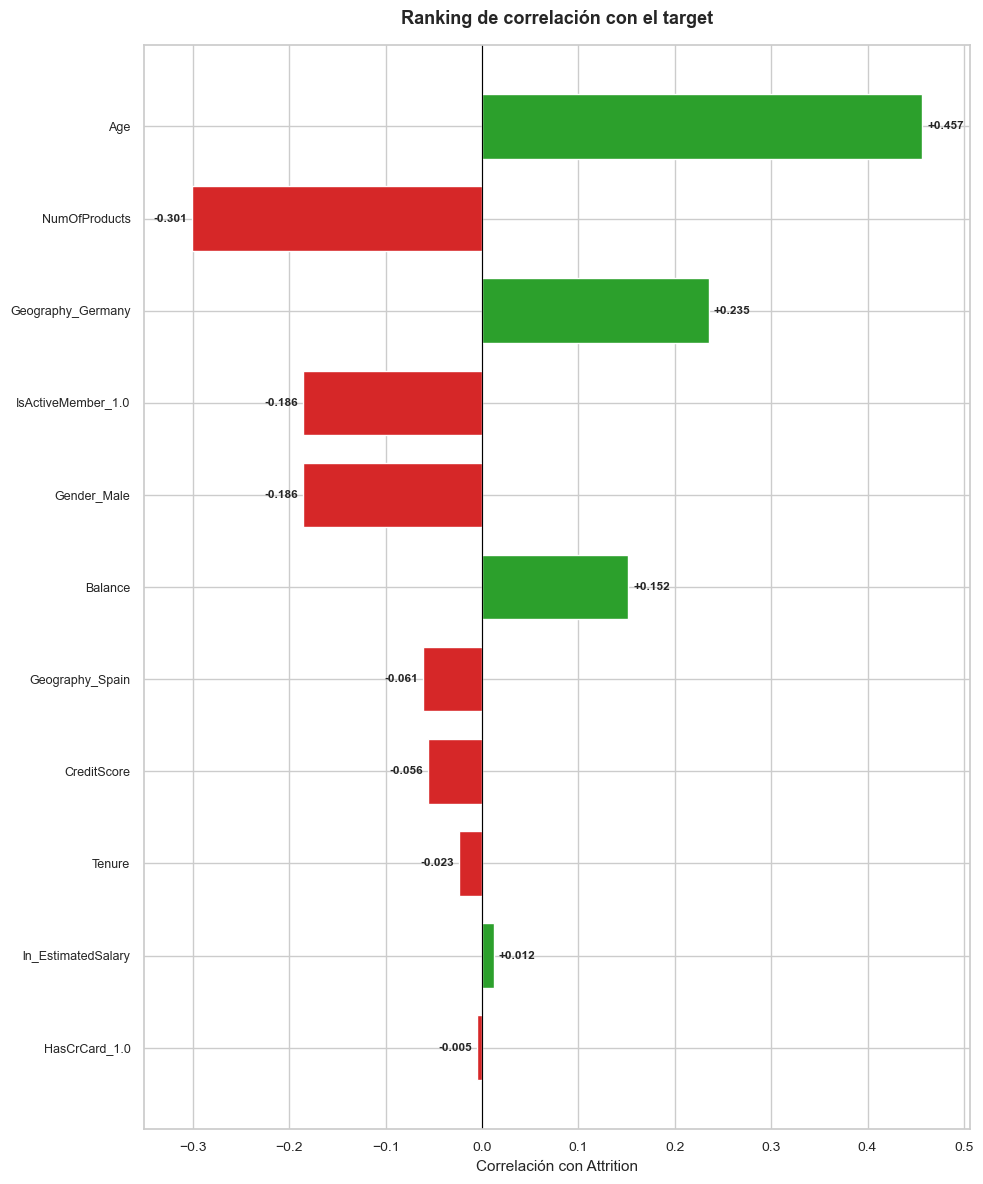

Ranking ordenado por correlación absoluta:
Age                   0.46
NumOfProducts        -0.30
Geography_Germany     0.23
IsActiveMember_1.0   -0.19
Gender_Male          -0.19
Balance               0.15
Geography_Spain      -0.06
CreditScore          -0.06
Tenure               -0.02
ln_EstimatedSalary    0.01
HasCrCard_1.0        -0.01
Name: Exited, dtype: float64


In [13]:
# 10. REALIZAR ANALISIS DE CORRELACION CON EL TARGET ---

# PREPARAR DATOS PARA ANALISIS DE CORRELACION ----------------------------------

# Entrenar el preprocesador con X_train y aplicar la transformación
X_train_transf = preprocesador.fit_transform(X_train)

# Aplicar a todo X el preprocesador entrenado con X_train
X_transf = preprocesador.transform(X)

# Recuperar nombres de columnas resultantes para poner en DataFrame
ohe_cat_cols = list(preprocesador.named_transformers_['codificar_cat'].get_feature_names_out(cat_features))
ohe_bin_cols = list(preprocesador.named_transformers_['codificar_bin'].get_feature_names_out(bin_features))
col_names_final = num_features + ohe_cat_cols + ohe_bin_cols

# Construir un DataFrame de datos transformados con nombres más el target
df_num = pd.DataFrame(X_transf, columns=col_names_final, index=X.index)
df_num['Exited'] = y

# CONSTRUIR MATRIZ DE CORRELACION ----------------------------------------------

# Generar matriz de correlación de todo X con datos transformados
corr = df_num.corr()

# Definir tamaño de la representación gráfica de la matriz
plt.figure(figsize=(24, 20))

# Definir una paleta de colores para el ranking de correlación
PALETA = ['#2ca02c', '#d62728'] # Verde para positivo, Rojo para negativo

# Dibujar el mapa de calor ajustando el tamaño de la letra (annot_kws)
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75}, # Encoge la barra de color para que no deforme el mapa
            annot_kws={"size": 8})     # Reducir la letra de los números dentro de las celdas

# Rotar las etiquetas para que no se encimen
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.title('Matriz de correlación (Pearson)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# -- GENERAR RANKING DE CORRELACION CON EL TARGET ------------------------------

# Extraer columna target y ordenar por valor absoluto del coef. correlación
corr_target = corr['Exited'].drop('Exited')
ranking = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

# Aumentamos el alto a 12 para que cada barra tenga su propio espacio respirable
fig, ax = plt.subplots(figsize=(10, 12))

colores = [PALETA[0] if v >= 0 else PALETA[1] for v in ranking]

# Ajustar el grosor de las barras con height=0.7 para dejar separación entre ellas
ax.barh(ranking.index, ranking.values, color=colores, height=0.7)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlabel('Correlación con Attrition', fontsize=11)
ax.set_title('Ranking de correlación con el target', fontweight='bold', fontsize=13, pad=15)
ax.invert_yaxis()

# Reducir el tamaño de letra de los nombres de las variables
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=10)

# Corregir las etiquetas de texto para que no colisionen con las barras
for i, v in enumerate(ranking.values):
    # El desplazamiento (offset) depende de si el valor es positivo o negativo
    offset = 0.005 if v >= 0 else -0.005
    alignment = 'left' if v >= 0 else 'right'

    ax.text(v + offset, i, f'{v:+.3f}',
            va='center',
            ha=alignment,
            fontsize=8.5,
            fontweight='semibold')

# Añadir margen a los lados del gráfico para que los textos de las puntas no se corten
ax.set_xlim(ranking.min() - 0.05, ranking.max() + 0.05)

plt.tight_layout()
plt.show()

print('Ranking ordenado por correlación absoluta:')
print(ranking.round(3))

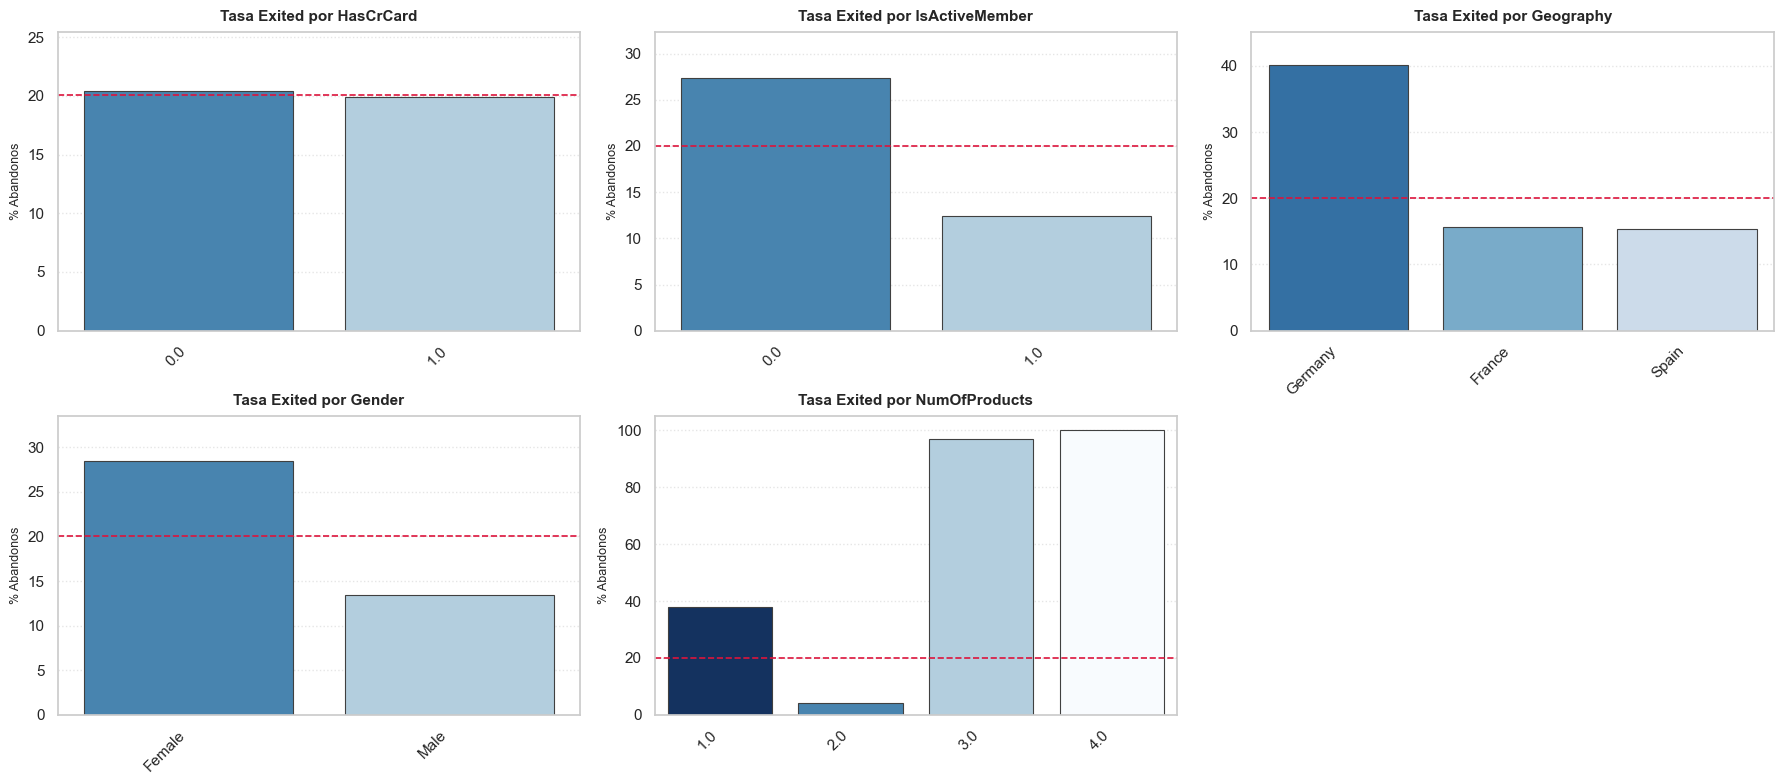

In [14]:
# Barplots de tasa de Exited por categoría.

import math

#Creamos la copia de trabajo y pasamos el target a porcentaje directo (0 a 100%)
df_plot = df_depurado.copy()
df_plot['Exited_Percent'] = df_plot['Exited'].map({1: 100, 0: 0})

# Agrupamos las listas categóricas y numéricas de la auditoría limpia
# Le agrego temporalmente NumOfProducts a las categoricas para poder graficar la tasa de abandono 
# por cantidad de productos y que quede bien

variables_categoricas = bin_features + cat_features  + ['NumOfProducts']
variables_numericas = num_features

# Configuramos una cuadrícula fija de 3 columnas
n_cols = 3
# Calculamos las filas necesarias de forma dinámica (redondeando hacia arriba)
n_rows = math.ceil(len(variables_categoricas) / n_cols)

# Creamos la figura principal con un tamaño proporcional al número de filas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))

# Aplanamos el array de ejes (axes) para poder iterar fácilmente en un solo bucle for
axes = axes.flatten()

# ==============================================================================
# BUCLE EN MATRIZ DE SUBPLOTS
# ==============================================================================
for i, var in enumerate(variables_categoricas):
    # Seleccionamos el eje (subgráfico) actual
    ax = axes[i]
    
    # Agrupamos por la variable, calculamos el porcentaje y ordenamos de mayor a menor riesgo (menos a las categoricas ordinales, que se plotean con el orden natural sin importar el porcentaje de renuncia)
    data_tasa = df_plot.groupby(var)['Exited_Percent'].mean().sort_values(ascending=False).reset_index()
    
    # Dibujamos el barplot en el eje correspondiente (ax=ax)
    sns.barplot(
        x=var, 
        y='Exited_Percent', 
        data=data_tasa, 
        palette='Blues_r', 
        hue=var,
        legend=False,
        ax=ax,
        edgecolor='#404040', 
        linewidth=0.8
    )
    
    # Añadimos la línea roja horizontal con la tasa base del 16% en cada subgráfico 
    ax.axhline(y=20.04, color='crimson', linestyle='--', linewidth=1.2, label='Base (20.04%)' if i == 0 else "")
    
    ax.set_title(f'Tasa Exited por {var}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('') 
    ax.set_ylabel('% Abandonos', fontsize=9)
    ax.set_ylim(0, max(data_tasa['Exited_Percent'].max() + 5, 25))
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show() 


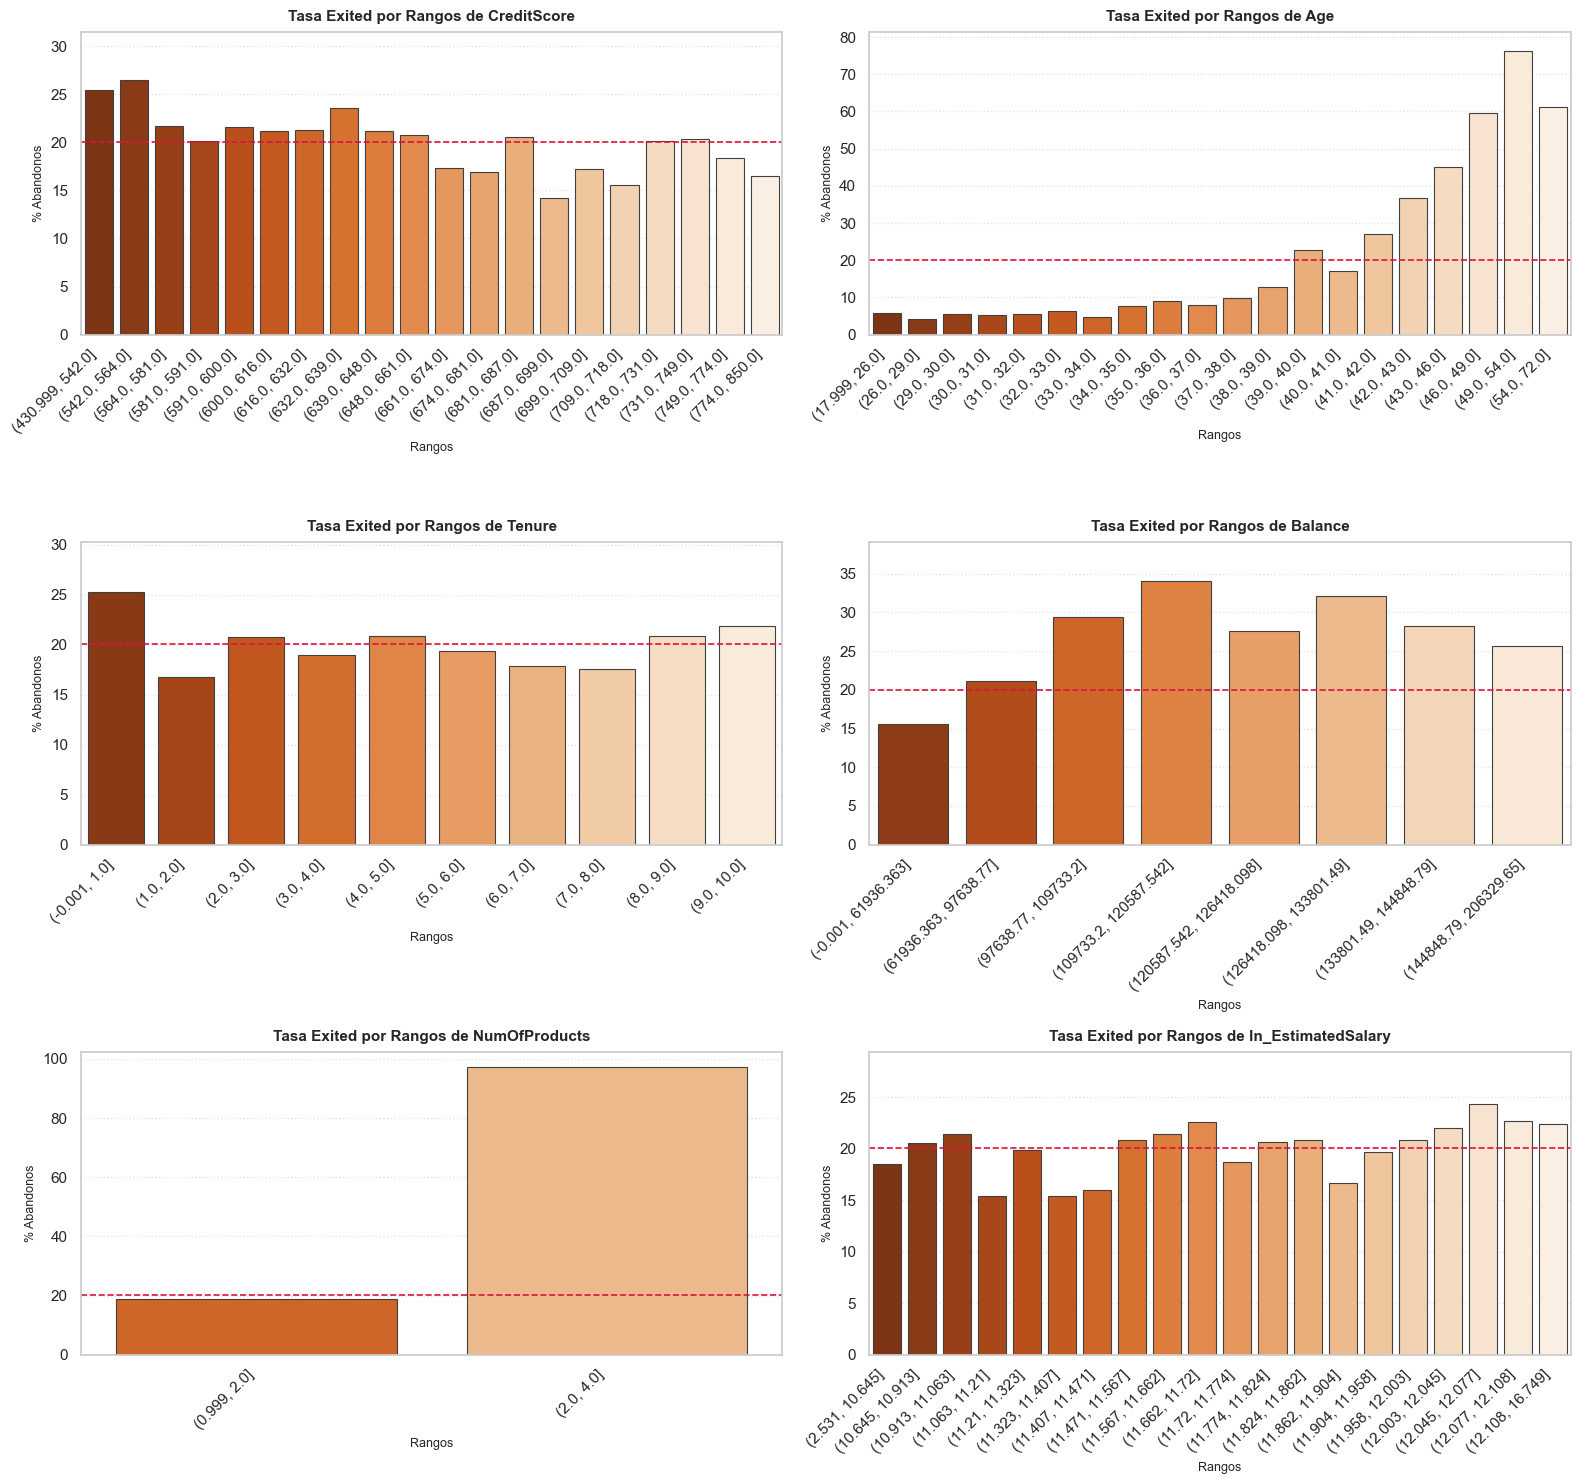

In [15]:

# Hacemos lo mismo pero para las variables numericas, pero a estas las tendremos que dividir en rangos para los graficos de barras. 

n_cols = 2
# Calculamos las filas necesarias de forma dinámica
n_rows = math.ceil(len(variables_numericas) / n_cols) 


fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

# Aplanamos el array de ejes para poder iterar en un solo bucle limpio (aplasta una matriz 2D en 1D)
axes = axes.flatten()

# ==================================================================================================
# BUCLE EN MATRIZ DE SUBPLOTS
# ==================================================================================================
for i, var in enumerate(variables_numericas):
    ax = axes[i]
    col_intervalo = f'{var}_Rango'
    
    # Segmentamos la variable numérica continua en 10 deciles
    # Usamos duplicates='drop' por seguridad si hay muchos valores idénticos (por lo que algunas variables no quedaran con 10 rangos)
    df_plot[col_intervalo] = pd.qcut(df_plot[var], q=20, duplicates='drop')

    data_tasa_num = (
        df_plot.groupby(col_intervalo, observed=True)['Exited_Percent']
        .mean()
        .sort_index()
        .reset_index()
    )

    data_tasa_num[col_intervalo] = data_tasa_num[col_intervalo].astype(str)
    
    # Dibujamos el barplot en el eje correspondiente
    sns.barplot(
        x=col_intervalo, 
        y='Exited_Percent', 
        data=data_tasa_num, 
        palette='Oranges_r',
        hue=col_intervalo,
        legend=False,
        ax=ax,
        edgecolor='#404040', 
        linewidth=0.8
    )
    
    # Añadimos la línea roja con la tasa base del 16% global de la empresa
    ax.axhline(y=20.04, color='crimson', linestyle='--', linewidth=1.2, label='Base Global (20.04%)' if i == 0 else "")
    
    ax.set_title(f'Tasa Exited por Rangos de {var}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Rangos', fontsize=9) 
    ax.set_ylabel('% Abandonos', fontsize=9)
    ax.set_ylim(0, max(data_tasa_num['Exited_Percent'].max() + 5, 25))
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

### Observaciones generales:
---
1)  **En _NumOfProducts_ claramente hay una diferencia entre los que tienen 1 o 2 productos a los que tienen 3 o 4. Una idea es juntar esos grupos y hacerlo binario para mas generalización.**
---
2) **Gran correlacion de Exited con la edad, a mayor edad, crece la tasa de Exited.**
---
3) **Se utilizó el logaritmo natural del estimativo del salario ya que la distribucion original es sesgada hacia la derecha y con alta varianza.**
---
4) **En _Geography_, Alemania tiene una tasa mucho mas alta que Francia y España.**
---

## 2) Modelo de Neural Network (MLP)
Entrenamiento base de una red neuronal para predecir `Exited` usando `Pipeline` + `ColumnTransformer`.

### 2.1) Búsqueda de hiperparámetros (RandomizedSearchCV)
Antes de fijar una arquitectura final, buscamos combinaciones candidatas para la red neuronal usando validación cruzada y AUC como métrica objetivo.

In [ ]:
# 11. BUSQUEDA DE HIPERPARAMETROS PARA MLP
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

nn_pipe = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('mlp', MLPClassifier(
        random_state=42,
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

param_dist = {
    'mlp__hidden_layer_sizes': [(32,), (64,), (64, 32), (14, 7, 32), (32, 16, 8), (64, 32, 16), (16, 8, 4), (16, 8, 4, 2)],
    'mlp__activation': ['relu'],
    'mlp__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1],
    'mlp__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    'mlp__batch_size': [8, 16, 32, 64, 128]
}

nn_search = GridSearchCV(
    estimator=nn_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    n_jobs=7,
    verbose=1,
    random_state=42
)

nn_search.fit(X_train, y_train)

print('Mejor AUC CV:', round(nn_search.best_score_, 4))
print('Mejores hiperparametros:')
for k, v in nn_search.best_params_.items():
    print(f'  - {k}: {v}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor AUC CV: 0.9292
Mejores hiperparametros:
  - mlp__learning_rate_init: 0.001
  - mlp__hidden_layer_sizes: (16, 8, 4)
  - mlp__batch_size: 8
  - mlp__alpha: 0.01
  - mlp__activation: relu


---
#### Con:

```python
param_dist = {
    'mlp__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64), (128, 64, 32), (14, 7, 32), (32, 16, 8), (64, 32, 16), (128, 64, 32, 16)],
    'mlp__activation': ['relu'],
    'mlp__alpha': [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1],
    'mlp__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    'mlp__batch_size': [16, 32, 64, 128, 256]
}
```

#### Obtengo: 

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor AUC CV: 0.929
Mejores hiperparametros:
  - mlp__learning_rate_init: 0.0005
  - mlp__hidden_layer_sizes: (32, 16, 8)
  - mlp__batch_size: 8
  - mlp__alpha: 0.01
  - mlp__activation: relu


---
#### Con:

```python
param_dist = {
    'mlp__hidden_layer_sizes': [(32,), (64,), (64, 32), (14, 7, 32), (32, 16, 8), (64, 32, 16), (16, 8, 4), (16, 8, 4, 2)],
    'mlp__activation': ['relu'],
    'mlp__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1],
    'mlp__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    'mlp__batch_size': [8, 16, 32, 64, 128]
}
```

#### Obtengo: 

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor AUC CV: 0.9292
Mejores hiperparametros:
  - mlp__learning_rate_init: 0.001
  - mlp__hidden_layer_sizes: (16, 8, 4)
  - mlp__batch_size: 8
  - mlp__alpha: 0.01
  - mlp__activation: relu
---

#### Con:

```python
param_dist = {
    'mlp__hidden_layer_sizes': [ (14, 7, 32), (32, 16, 8), (64, 32, 16), (16, 8, 4), (16, 8, 4, 2), (8, 4, 2), (8, 4, 4), (8, 4, 2, 4, 8), (7,3,7)],
    'mlp__activation': ['relu'],
    'mlp__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1],
    'mlp__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    'mlp__batch_size': [8, 16, 32, 64]
}
```

#### Obtengo:

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor AUC CV: 0.9289
Mejores hiperparametros:
  - mlp__learning_rate_init: 0.001
  - mlp__hidden_layer_sizes: (14, 7, 32)
  - mlp__batch_size: 8
  - mlp__alpha: 0.01
  - mlp__activation: relu
---


### Resultado de la búsqueda de hiperparámetros:

#### En las pruebas realizadas, el mejor modelo quedó con 3 capas con la estructura **(16, 8, 4)**. 

Mejor AUC CV: 0.9292
  - mlp__learning_rate_init: 0.001

  (es el tamaño del paso que realiza entre iteraciones para cambiar los pesos de las neuronas en la busqueda por descenso de gradiente, más pequeño significa mas presicion pero lentitud y posibilidad de quedar atrapado en minimos locales, mientras que grandes pueden escapar mas facilmente y son mas rapidos pero se pueden escapar de la solucion ideal con mas facilidad y oscilar mucho o ni siquiera converger)

  - mlp__hidden_layer_sizes: (16, 8, 4)

  (son tres capas, la primera con 16 neuronas, la segunda con 8 y la tercera con 4)

  - mlp__batch_size: 8

  (es el numero de observaciones que utiliza para calcular el gradiente, mientras mas pequeño mas ruido puede introducir pero puede servir para escapar minimos locales y generalizar mejor, mas grandes pueden mapear mejor el gradiente pero tambien corren el riesgo de no poder escapar minimos locales)

  - mlp__alpha: 0.01

  (es el termino de penalizacion para los pesos excesivamente grandes en la funcion de pérdida, mientras mas grandes, mas penalizacion y por lo tanto mayor reduccion del overfitting)

  - mlp__activation: relu

  (funcion de activacion de las neuronas para poder introducir no linealidad, ni siquiera probé con otra por lo que nos ha contado el profesor de que relu es la mejor)

AUC ROC (test) - mejor modelo: 0.9293

Classification Report (mejor modelo):
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93      2399
         1.0       0.74      0.72      0.73       601

    accuracy                           0.89      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.89      0.89      0.89      3000



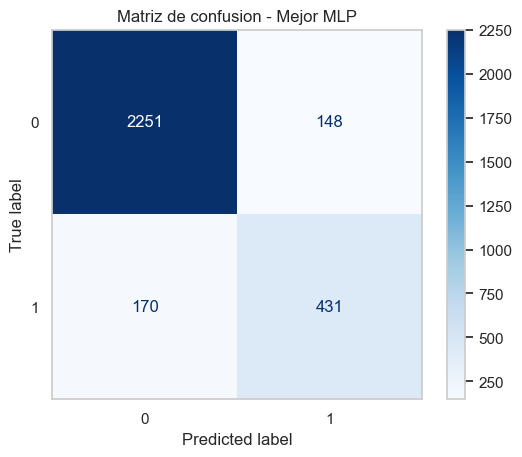

In [17]:
# 12. EVALUAR EL MEJOR MODELO EN TEST
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

best_nn_model = nn_search.best_estimator_

y_pred_best = best_nn_model.predict(X_test)
y_proba_best = best_nn_model.predict_proba(X_test)[:, 1]

print('AUC ROC (test) - mejor modelo:', round(roc_auc_score(y_test, y_proba_best), 4))
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor MLP')
plt.grid(False)
plt.show()